

# Graph Neural Networks for Polymer Band Gap Prediction

This tutorial guides you through building a **Graph Neural Network (GNN)** to predict the
electronic band gap ($E_g$) of polymers from their chemical repeat-unit structure. The band
gap (energy separation between the valence and conduction bands) is a critical design target
for organic photovoltaics, light-emitting devices, or gate dielectric applications.

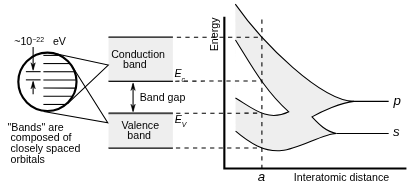

We represent each polymer repeat unit as a molecular graph
$\mathcal{G} = (\mathcal{V}, \mathcal{E})$
where nodes $v \in \mathcal{V}$ are atoms and edges $(u,v) \in \mathcal{E}$ are covalent
bonds. A GNN learns to map this variable-size graph to a scalar prediction through
iterative **message passing**.

**Learning objectives**

1. Parse polymer SMILES strings with RDKit and build PyG `Data` objects
2. Design chemically meaningful node feature vectors
3. Implement a graph-level task regression GNN using `GCNConv` and global mean pooling
4. Train and validate the model, monitoring overfitting via a held-out validation set
5. Assess predictive performance with MAE, RMSE, and $R^2$ on an independent test set


---
## Section 1: Setup and Imports

You will need those imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

from rdkit import Chem
from rdkit.Chem import rdchem

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

import torch_geometric

print(f"PyTorch            : {torch.__version__}")
print(f"PyTorch Geometric  : {torch_geometric.__version__}")
print(f"CUDA available     : {torch.cuda.is_available()}")

DEVICE = torch.device("cpu")
print(f"Using device       : {DEVICE}")

/home/chris/courses/et-in-mi-st26/.venv/lib/python3.12/site-packages/torch/__config__.py:9: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._show_config()


PyTorch            : 2.11.0+cu130
PyTorch Geometric  : 2.7.0
CUDA available     : False
Using device       : cpu


---
## Section 2: Data Loading and Preprocessing


The dataset is a DFT-level computational dataset of polymer electronic properties. Each row represents one polymer **repeat unit**
encoded as a SMILES string with `[*]` attachment-point wildcards.

The CSV has three columns:

| Column | Description |
|---|---|
| `smiles` | Repeat-unit PSMILES; `[*]` shows chain attachment points |
| `property` |  `Egc` (computed band gap) and others (ignore other properties) |
| `value` | Numerical value of the property |


---
### Notes on PSMILES

Standard SMILES strings encode molecules. Polymer repeat units (monomers) instead use attachment-point wildcards `[*]` (atomic number 0, symbol `*`) to mark where one repeat unit connects to the next:

```
[*]CC([*])C    ←  polypropylene monomer unit
 ↑     ↑
 polymer chain connection points
```

These star atoms are retained in the graph because they encode structural information about chain connectivity.


## Todo:
1. Load dataset from `https://raw.githubusercontent.com/kuennethgroup/materials_datasets/refs/heads/main/polymer_band_gap_computational/export.csv` using `pandas`
2. Exclude all properties except `property == 'Egc'` 
3. Count values, compute mean and standard deviation of the target property `Egc`
4. Plot the distribution of `Egc` values (e.g. histogram or KDE plot)


Shows the expected output, which you can use to verify

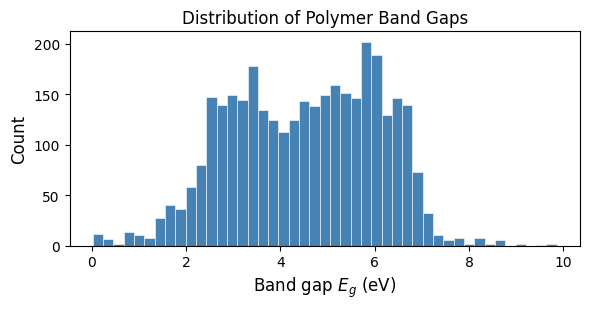

### 2.3 Building Molecular Graphs

A molecule with $N$ atoms becomes a PyG `Data` object containing:

- **Node feature matrix** $\mathbf{X} \in \mathbb{R}^{N \times d}$ — one row per atom
- **Edge index** $\mathbf{E} \in \mathbb{Z}^{2 \times 2|\text{bonds}|}$ — each bond
  appears twice (both directions) to model undirected communication
- **Graph label** $y \in \mathbb{R}$ — the band gap in eV

We use a 25-dimensional node feature vector:

| Feature group | Encoding | Dimensionality |
|---|---|---|
| Atom symbol | One-hot over `{C, N, O, F, P, S, Cl, Br, Si, *}` | 10 |
| Degree | One-hot over $\{0,1,2,3,4,5,6\}$ | 7 |
| Is aromatic | Binary flag | 1 |
| Hybridisation | One-hot over `{SP, SP2, SP3, SP3D, SP3D2}` | 5 |
| Formal charge | Signed integer | 1 |
| Total H count | Non-negative integer | 1 |



In [ ]:
ATOM_SYMBOLS = ["C", "N", "O", "F", "P", "S", "Cl", "Br", "Si", "*"]
HYBRIDIZATIONS = [
    rdchem.HybridizationType.SP,
    rdchem.HybridizationType.SP2,
    rdchem.HybridizationType.SP3,
    rdchem.HybridizationType.SP3D,
    rdchem.HybridizationType.SP3D2,
]


def one_hot(value, choices):
    """Return a one-hot list; all-zero vector if value not in choices."""
    enc = [0] * len(choices)
    if value in choices:
        enc[choices.index(value)] = 1
    return enc


def atom_features(atom):
    """
    Compute the 25-dimensional feature vector for each atom.

    RDKit atom methods to compute the features.
    Use them line by line to get the necessary information about the atom:
    E.g. for the first feature (atom symbol), use `atom.GetSymbol()` to get the symbol of the atom, 
    then apply `one_hot()` to get the one-hot encoding: one_hot(atom.GetSymbol(), ATOM_SYMBOLS)
        atom.GetSymbol()          -> str,  e.g. 'C', 'N', '*'
        atom.GetDegree()          -> int,  number of explicit bonds
        atom.GetIsAromatic()      -> bool
        atom.GetHybridization()   -> rdchem.HybridizationType
        atom.GetFormalCharge()    -> int
        atom.GetTotalNumHs()      -> int,  includes implicit H

    Concatenate all features into a single list and return it.
    """
    
    


# Sanity check here, we use the method later
_mol = Chem.MolFromSmiles("[*]CC([*])C")
_feat = atom_features(_mol.GetAtomWithIdx(0))
print(f"Feature vector length : {len(_feat)}")

In [ ]:
# Next, we implement the main function to convert a SMILES string to a PyG Data object,
# which will be used to create our dataset.


def smiles_to_graph(smiles: str, y_val: float):
    """
    Convert a PSMILES string to a PyG Data object

    Instructions:
    1. Parse `smiles` with Chem.MolFromSmiles() from RDKit. 
       Return None on failure: `if mol is None: return None`.
    2. Build the node feature matrix x of shape [N, 25] using atom_features().
       Use torch.tensor(..., dtype=torch.float) and iterate over mol.GetAtoms() 
       to get the features for each atom.
    3. Build the edge_index tensor of shape [2, 2*num_bonds].
       Iterate over mol.GetBonds(); for each bond with atom indices i and j,
       add BOTH [i, j] and [j, i] to capture the undirected graph.
       Handle the edge case of zero bonds (isolated atoms).
       NOTE: bond.GetBeginAtomIdx() and bond.GetEndAtomIdx() give the indices of the two atoms in the bond.
       edge_list should be a list of pairs [[i, j], [j, i], ...] that you can convert to a torch tensor
    4. Create the label tensor y of shape [1, 1] from y_val.
    5. Return Data(x=x, edge_index=edge_index, y=y).
    """
    
    


# Test - should print a data object with num_nodes > 0
example = smiles_to_graph("[*]Oc1ccc(Cc2ccc([*])cc2)cc1", 3.85)
print(example)

In [ ]:
# After correctly completing the previous cell, this should run and produce statistics 
data_list, failed = [], 0

# df is the dataframe that you import at the beginning after filtering
for _, row in df.iterrows():
    g = smiles_to_graph(row['smiles'], row['value'])
    if g is not None:
        data_list.append(g)
    else:
        failed += 1

print(f'Converted : {len(data_list)}')
print(f'Failed    : {failed}')

num_nodes = [d.num_nodes for d in data_list]
num_edges = [d.num_edges // 2 for d in data_list]   # bonds, not directed edges
print(f'Atoms / repeat unit    : {np.mean(num_nodes):.1f} ± {np.std(num_nodes):.1f}')
print(f'Bonds / repeat unit    : {np.mean(num_edges):.1f} ± {np.std(num_edges):.1f}')


---
## Section 3: Creating the PyG Dataset and DataLoaders

### Batching variable-size graphs

Molecular graphs vary in node and edge count. PyTorch Geometric and other tools handle
this through **disjoint graph batching**: $B$
graphs are merged into a single large disconnected graph by block-diagonalising their
adjacency matrices and vertically stacking node features:

$$
\mathbf{X}^{\text{batch}} = \begin{bmatrix} \mathbf{X}_1 \\ \vdots \\ \mathbf{X}_B \end{bmatrix}
\in \mathbb{R}^{(\sum_i N_i) \times d}, \qquad
\mathbf{A}^{\text{batch}} = \operatorname{blkdiag}(\mathbf{A}_1, \ldots, \mathbf{A}_B)
$$

A companion `batch` vector of shape $[\sum_i N_i]$ records which graph each node belongs
to, enabling backtracing and graph-level aggregations like `global_mean_pool`.

We split the 1 127-sample dataset 70 / 15 / 15 % into train, validation, and test sets
with a fixed random seed for reproducibility.


In [ ]:
# Set the seeds for reproducibility
import random
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

n = len(data_list)

# Instructions:
# 1. Create a shuffled list of indices (0 to n-1)
# 2. Compute n_train = 70% of n, n_val = 15% of n.
# 3. Slice into train_idx, val_idx, test_idx.
# 4. Build train_data, val_data, test_data as lists of Data objects.

print(f'Train : {len(train_data)}')
print(f'Val   : {len(val_data)}')
print(f'Test  : {len(test_data)}')

BATCH_SIZE = 32

# TODO: Create train_loader (shuffle=True), val_loader (shuffle=False), and test_loader (shuffle=False)
# using PyG's DataLoader with BATCH_SIZE: train_loader = DataLoader(...) etc.


In [ ]:
# Run this after implementing the DataLoaders to see the structure of a batch
batch = next(iter(train_loader))
print('Batch object  :', batch)
print('x shape       :', batch.x.shape)            # [total_nodes, 25]
print('edge_index    :', batch.edge_index.shape)    # [2, total_directed_edges]
print('y shape       :', batch.y.shape)             # [batch_size, 1]
print('batch vector  :', batch.batch.shape)         # [total_nodes]
print('Unique graphs :', batch.batch.max().item() + 1)


---
## Section 4: Building the GNN Model

Architecture diagram:

```
Input  (25-dim node features)
  │
  ├── GCNConv(25 → 128) + BatchNorm1d + ReLU
  ├── GCNConv(128 → 128) + BatchNorm1d + ReLU
  └── GCNConv(128 → 128) + BatchNorm1d + ReLU
  │
  global_mean_pool          → [batch_size, 128]
  │
  ├── Linear(128 → 64) + ReLU + Dropout(p=0.2)
  └── Linear(64 → 1)          → predicted Eg (eV)
```


In [ ]:
class PolymerGNN(nn.Module):
    """Graph Convolutional Network for polymer band-gap regression."""

    def __init__(self, in_channels: int, hidden_channels: int = 128, num_conv_layers: int = 3):
        super().__init__()

        # 
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        # Convolution + BatchNorm layers
        # Instruction: Add GCNConv(in_channels, hidden_channels) and a matching
        #       BatchNorm1d(hidden_channels) as the first conv layer.
        # Then add (num_conv_layers - 1) additional GCNConv(hidden -> hidden)
        # layers, each with its own BatchNorm1d to self.convs and self.bns.

        # Regression head
        # Instruction: 
        # Define two linear layers: 
        # self.lin1 maps Linear(hidden_channels -> hidden_channels//2)
        # and maps self.lin2 Linear(hidden_channels//2 -> 1).

    def forward(self, x, edge_index, batch):
        """Forward pass of the GNN."""
        # Iterate over self.convs and self.bns.
        # For each (conv, bn) pair:
        #   x = conv(x, edge_index) # aggregate messages from neighbors
        #   x = bn(x) # to stabilize gradients
        #   x = F.relu(x) # activations function

        # Graph readout
        # Use global_mean_pool(x, batch) to obtain one vector per graph.


        # Regression head:
        # Apply lin1 + ReLU + Dropout(p=0.2, training=self.training) + lin2.
        # Return x.squeeze(-1) so the output shape is [batch_size].
    


IN_CHANNELS = data_list[0].x.shape[1]   
model = PolymerGNN(in_channels=IN_CHANNELS, hidden_channels=128, num_conv_layers=3).to(DEVICE)
print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters : {n_params:,}')


You will see something like:
```
PolymerGNN(
  (convs): ModuleList(
    (0): GCNConv(25, 128)
    (1-2): 2 x GCNConv(128, 128)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (lin1): Linear(in_features=128, out_features=64, bias=True)
  (lin2): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters : 45,441
```

---
## Section 5: Training Loop

We minimise the MSE:

$$
\mathcal{L}_{\text{MSE}} = \frac{1}{N}\sum_{i=1}^{N}\!\left(\hat{y}_i - y_i\right)^2
$$

MSE penalises large errors quadratically and assumes roughly Gaussian noise around the
true band gap.

We use **Adam** optimizer and a `ReduceLROnPlateau` scheduler.


In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    """
    Run one full training epoch.

    Instructions:
    1. Set model to training mode.
    2. Loop over batches in loader.
       a. Move batch to DEVICE.
       b. Zero gradients.
       c. Forward pass: pred = model(batch.x, batch.edge_index, batch.batch)
       d. Compute loss against batch.y.squeeze(-1).
       e. Backpropagate and step the optimizer.
       f. Accumulate weighted loss (loss * batch.num_graphs) and sample count.
    3. Return mean loss (total_loss / total_samples).
    """
    model.train()
    total_loss, total_n = 0.0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        # Instructions: implement training step
    return total_loss / total_n

@torch.no_grad()
def evaluate(model, loader, criterion):
    """Evaluate on a DataLoader without gradient tracking; return mean MSE."""
    model.eval()
    total_loss, total_n = 0.0, 0

    for batch in loader:
        batch = batch.to(DEVICE)
        pred = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(pred, batch.y.squeeze(-1))

        total_loss += loss.item() * batch.num_graphs
        total_n += batch.num_graphs

    return total_loss / total_n


In [ ]:
# Some constants
EPOCHS = 150
LR = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=15,
    min_lr=1e-5,
)

train_losses, val_losses = [], []

# Instructions: Fill in the training loop.
# For each epoch:
#   1. Call train_epoch -> tr_loss
#   2. Call evaluate on val_loader -> val_loss
#   3. Step the scheduler with val_loss
#   4. Append both losses to train_losses / val_losses
#   5. Print progress every 15 epochs and at epoch 1

In [ ]:
# Plot the training vs validation MSE error
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, label='Train MSE', linewidth=1.5)
ax.plot(val_losses,   label='Val MSE',   linewidth=1.5, linestyle='--')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE  (eV²)', fontsize=12)
ax.set_title('Learning Curves', fontsize=13)
ax.set_yscale('log')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


---
## Section 6: Evaluation

We report three standard regression metrics on the held-out test set: MAE, RMSE, and $R^2$.

The **parity plot** (predicted vs. actual) is the canonical visualisation in
computational materials science. Scatter close to the diagonal $\hat{y} = y$ indicates
good generalisation. Systematic offsets at either end of the range suggest that the model
struggles with the extremes of the band-gap distribution and may benefit from more data
or additional structural descriptors.


In [ ]:
@torch.no_grad()
def get_predictions(model, loader):
    """Collect all predictions and ground-truth labels as NumPy arrays."""
    model.eval()
    preds, targets = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        pred  = model(batch.x, batch.edge_index, batch.batch)
        preds.append(pred.cpu().numpy())
        targets.append(batch.y.squeeze(-1).cpu().numpy())
    return np.concatenate(preds), np.concatenate(targets)


y_pred, y_true = get_predictions(model, test_loader)

# Instruction: Compute and print the three metrics using scikit-learn / numpy.
#   mae  = mean_absolute_error(y_true, y_pred)
#   rmse = sqrt of mean squared error (compute manually with numpy)
#   r2   = r2_score(y_true, y_pred)


In [ ]:
# TODO: Create a parity plot of predicted vs. actual band gaps (see parity_plot.png for reference)
#
# Requirements:
#   - Scatter plot of (y_true, y_pred) with semi-transparent markers
#   - A dashed diagonal line representing perfect prediction (y_hat = y)
#   - Equal aspect ratio and matching axis limits
#   - Axis labels: 'DFT Band Gap (eV)' and 'GNN Predicted Band Gap (eV)'
#   - A text box in the upper-left corner showing MAE, RMSE, and R²
#   - Save the figure to 'parity_plot.png' at 150 dpi

